# LBG Classification Model Training

This notebook trains and evaluates LightGBM models for LBG classification. 

## Strategy
- Phase 1: Train on 70%, evaluate on 30% test set
- Phase 2: Train final model on 100% data
- Compare 3 feature sets

In [18]:
# ## Cell 1: Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)
import lightgbm as lgb
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Imports completed.")
print(f"LightGBM version: {lgb.__version__}")

Imports completed.
LightGBM version: 4.6.0


In [19]:
# ## Cell 2: Configuration

# =============================================================================
# CONFIGURATION
# =============================================================================

# --- Paths ---
DATA_PATH = "../data_processed/training_dataset_v2.csv"  # Updated to V2
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

# --- Random seed ---
RANDOM_STATE = 42

# --- Train/Test split ---
TEST_SIZE = 0.30
CV_FOLDS = 5

# --- Feature sets to compare ---
FEATURE_SETS = {
    # Full features (may have NaN in mag_u, u_g, etc.)
    'full': [
        'mag_u', 'mag_g', 'mag_r', 'mag_i', 'mag_z', 'mag_y',
        'err_u', 'err_g', 'err_r', 'err_i', 'err_z', 'err_y',
        'u_g', 'g_r', 'r_i', 'i_z', 'z_y'
    ],
    # Core features with detection flags
    'core_flag':  [
        'u_g', 'g_r', 'r_i', 'i_z', 'z_y',
        'mag_i',
        'flag_u', 'flag_g', 'flag_r', 'flag_i', 'flag_z', 'flag_y'
    ],
    # Core features with errors
    'core_err': [
        'u_g', 'g_r', 'r_i', 'i_z', 'z_y',
        'mag_i',
        'err_u', 'err_g', 'err_r', 'err_i', 'err_z', 'err_y'
    ],
    # Flag-focused (minimal NaN, emphasize detection info)
    'flag_focus': [
        'flag_u', 'flag_g', 'flag_r', 'flag_i', 'flag_z', 'flag_y',
        'g_r', 'r_i', 'i_z',  # Colors with less NaN
        'mag_i', 'mag_g',
        'err_g', 'err_i'
    ],
}

# --- LightGBM parameters ---
LGBM_PARAMS = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'max_depth': -1,
    'learning_rate': 0.05,
    'n_estimators': 500,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda':  0.1,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbose': -1,
}

LABEL_COL = 'is_lbg'

print("Configuration loaded.")
print(f"Data path: {DATA_PATH}")
print(f"Test size: {TEST_SIZE*100:.0f}%")
print(f"Feature sets: {list(FEATURE_SETS.keys())}")

Configuration loaded.
Data path: ../data_processed/training_dataset_v2.csv
Test size: 30%
Feature sets: ['full', 'core_flag', 'core_err', 'flag_focus']


In [20]:
# ## Cell 3: Load Data and Inspect V2 Changes

# Load data
df = pd.read_csv(DATA_PATH)
print(f"Loaded data:  {df.shape[0]} samples, {df.shape[1]} columns")

# Class distribution
print(f"\n[1] Class Distribution:")
print(f"    LBG: {(df[LABEL_COL]==1).sum()} ({(df[LABEL_COL]==1).mean()*100:.1f}%)")
print(f"    Non-LBG: {(df[LABEL_COL]==0).sum()} ({(df[LABEL_COL]==0).mean()*100:.1f}%)")

# Check NaN in features (key change in V2)
print(f"\n[2] NaN Values in Features (V2 - no filling):")
all_features = set()
for features in FEATURE_SETS.values():
    all_features.update(features)

for col in sorted(all_features):
    if col in df.columns:
        n_nan = df[col].isna().sum()
        if n_nan > 0:
            print(f"    {col}: {n_nan} NaN ({n_nan/len(df)*100:.1f}%)")

# Check detection rates
print(f"\n[3] Detection Rates (flag=1):")
for band in ['u', 'g', 'r', 'i']: 
    flag_col = f'flag_{band}'
    if flag_col in df. columns:
        det_rate = df[flag_col].mean() * 100
        print(f"    {band}-band: {det_rate:.1f}% detected")

# Check star removal
print(f"\n[4] Star Removal Verification:")
if 'class_star' in df.columns:
    cs = df['class_star'].dropna()
    n_stars = (cs > 0.8).sum()
    print(f"    Sources with CLASS_STAR > 0.8: {n_stars}")
    if n_stars == 0:
        print("    ✓ All photometric stars removed")

Loaded data:  3496 samples, 41 columns

[1] Class Distribution:
    LBG: 1893 (54.1%)
    Non-LBG: 1603 (45.9%)

[2] NaN Values in Features (V2 - no filling):
    g_r: 9 NaN (0.3%)
    i_z: 51 NaN (1.5%)
    mag_g: 6 NaN (0.2%)
    mag_i: 29 NaN (0.8%)
    mag_r: 3 NaN (0.1%)
    mag_u: 912 NaN (26.1%)
    mag_y: 754 NaN (21.6%)
    mag_z: 34 NaN (1.0%)
    r_i: 29 NaN (0.8%)
    u_g: 913 NaN (26.1%)
    z_y: 757 NaN (21.7%)

[3] Detection Rates (flag=1):
    u-band: 73.9% detected
    g-band: 99.8% detected
    r-band: 99.9% detected
    i-band: 99.2% detected

[4] Star Removal Verification:
    Sources with CLASS_STAR > 0.8: 0
    ✓ All photometric stars removed


In [21]:
# Cell 4: Prepare Data (NO NaN filling)

# Collect all features
all_features = set()
for features in FEATURE_SETS.values():
    all_features.update(features)

# Prepare X and y
X = df[list(all_features)].copy()
y = df[LABEL_COL].copy()

# KEY CHANGE: Do NOT fill NaN - LightGBM handles them natively
print("NaN handling: LightGBM will handle NaN values natively")
print(f"Total NaN in feature matrix: {X.isna().sum().sum()}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"\nData split:")
print(f"  Training: {len(X_train)} samples")
print(f"  Test:     {len(X_test)} samples")
print(f"\nClass distribution (training):")
print(f"  LBG: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"  Non-LBG: {(y_train==0).sum()} ({(1-y_train. mean())*100:.1f}%)")

NaN handling: LightGBM will handle NaN values natively
Total NaN in feature matrix: 3497

Data split:
  Training: 2447 samples
  Test:     1049 samples

Class distribution (training):
  LBG: 1325 (54.1%)
  Non-LBG: 1122 (45.9%)


In [24]:
# Cell 5: Training Functions

def train_and_evaluate(
    X_train:  pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd. Series,
    features: list,
    params: dict,
    cv_folds: int = 5,
    early_stopping_rounds:  int = 50
) -> dict:
    """
    Train LightGBM model and evaluate. 
    NaN values are handled natively by LightGBM.
    """
    
    X_tr = X_train[features].copy()
    X_te = X_test[features].copy()
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_tr, y_train)):
        X_fold_train = X_tr.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val = X_tr.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]
        
        train_data = lgb.Dataset(X_fold_train, label=y_fold_train)
        val_data = lgb.Dataset(X_fold_val, label=y_fold_val, reference=train_data)
        
        model = lgb.train(
            params,
            train_data,
            valid_sets=[val_data],
            callbacks=[
                lgb.early_stopping(stopping_rounds=early_stopping_rounds, verbose=False),
                lgb.log_evaluation(period=0)
            ]
        )
        
        y_pred_val = model.predict(X_fold_val)
        fold_auc = roc_auc_score(y_fold_val, y_pred_val)
        cv_scores.append(fold_auc)
    
    cv_mean = np.mean(cv_scores)
    cv_std = np.std(cv_scores)
    
    # Train final model
    X_tr_final, X_val_final, y_tr_final, y_val_final = train_test_split(
        X_tr, y_train, test_size=0.1, random_state=RANDOM_STATE, stratify=y_train
    )
    train_data_final = lgb.Dataset(X_tr_final, label=y_tr_final)
    val_data_final = lgb. Dataset(X_val_final, label=y_val_final, reference=train_data_final)
    
    final_model = lgb.train(
        params,
        train_data_final,
        valid_sets=[val_data_final],
        callbacks=[
            lgb.early_stopping(stopping_rounds=early_stopping_rounds, verbose=False),
            lgb.log_evaluation(period=0)
        ]
    )
    
    # Evaluate on test set
    y_pred_proba = final_model.predict(X_te)
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    test_metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision':  precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_pred_proba),
    }
    
    importance = pd.DataFrame({
        'feature': features,
        'importance': final_model.feature_importance(importance_type='gain')
    }).sort_values('importance', ascending=False)
    
    return {
        'model': final_model,
        'cv_scores': cv_scores,
        'cv_mean': cv_mean,
        'cv_std': cv_std,
        'test_metrics': test_metrics,
        'y_pred_proba': y_pred_proba,
        'y_pred': y_pred,
        'feature_importance': importance,
        'features': features,
    }


def print_results(name: str, results: dict):
    """Print evaluation results."""
    print(f"\n{'='*60}")
    print(f"Results:  {name}")
    print(f"{'='*60}")
    print(f"\nCV AUC: {results['cv_mean']:.4f} ± {results['cv_std']:.4f}")
    print(f"Test metrics:")
    for metric, value in results['test_metrics'].items():
        print(f"  {metric:12s}: {value:.4f}")
    print(f"\nTop 5 features:")
    print(results['feature_importance'].head().to_string(index=False))


print("Training functions defined.")

Training functions defined.


In [25]:
# Cell 6: Train All Models

all_results = {}

for name, features in FEATURE_SETS.items():
    print(f"\n{'#'*60}")
    print(f"Training:  {name}")
    print(f"Features ({len(features)}): {features}")
    print(f"{'#'*60}")
    
    results = train_and_evaluate(
        X_train, y_train,
        X_test, y_test,
        features=features,
        params=LGBM_PARAMS,
        cv_folds=CV_FOLDS,
        early_stopping_rounds=50
    )
    
    all_results[name] = results
    print_results(name, results)


############################################################
Training:  full
Features (17): ['mag_u', 'mag_g', 'mag_r', 'mag_i', 'mag_z', 'mag_y', 'err_u', 'err_g', 'err_r', 'err_i', 'err_z', 'err_y', 'u_g', 'g_r', 'r_i', 'i_z', 'z_y']
############################################################

Results:  full

CV AUC: 0.7385 ± 0.0176
Test metrics:
  accuracy    : 0.6959
  precision   : 0.7072
  recall      : 0.7482
  f1          : 0.7271
  auc         : 0.7606

Top 5 features:
feature  importance
    r_i 3289.690478
    u_g 1699.109002
  err_u 1192.270448
    i_z 1044.467121
  mag_z 1020.713062

############################################################
Training:  core_flag
Features (12): ['u_g', 'g_r', 'r_i', 'i_z', 'z_y', 'mag_i', 'flag_u', 'flag_g', 'flag_r', 'flag_i', 'flag_z', 'flag_y']
############################################################

Results:  core_flag

CV AUC: 0.7278 ± 0.0164
Test metrics:
  accuracy    : 0.6873
  precision   : 0.6881
  recall      : 0.7729
  

In [26]:
# Cell 7: Compare Results

print("=" * 70)
print("FEATURE SET COMPARISON (V2 Dataset)")
print("=" * 70)

comparison = pd.DataFrame({
    name: {
        'CV AUC': f"{r['cv_mean']:.4f} ± {r['cv_std']:.4f}",
        'Test AUC': r['test_metrics']['auc'],
        'Test Accuracy': r['test_metrics']['accuracy'],
        'Test Precision': r['test_metrics']['precision'],
        'Test Recall': r['test_metrics']['recall'],
        'Test F1': r['test_metrics']['f1'],
        'Num Features': len(r['features']),
    }
    for name, r in all_results.items()
}).T

print("\n" + comparison.to_string())

best_name = max(all_results. keys(), key=lambda x: all_results[x]['test_metrics']['auc'])
print(f"\n★ Best model: {best_name}")

FEATURE SET COMPARISON (V2 Dataset)

                     CV AUC  Test AUC Test Accuracy Test Precision Test Recall   Test F1 Num Features
full        0.7385 ± 0.0176  0.760616      0.695901       0.707155    0.748239  0.727117           17
core_flag   0.7278 ± 0.0164  0.761429      0.687321       0.688088    0.772887  0.728027           12
core_err    0.7426 ± 0.0206  0.763848      0.686368       0.697521    0.742958  0.719523           12
flag_focus  0.7325 ± 0.0161  0.747939      0.686368       0.689382    0.765845  0.725605           13

★ Best model: core_err


In [29]:
# ## Cell 8: Diagnostic - Check if V2 Changes Improved Separation

print("=" * 70)
print("V2 DIAGNOSTIC:  Feature Separation Analysis")
print("=" * 70)

# Check if flag_u now shows expected pattern
print("\n[1] u-band Detection by Class:")
if 'flag_u' in df.columns:
    det_lbg = df[df['is_lbg']==1]['flag_u'].mean() * 100
    det_non_lbg = df[df['is_lbg']==0]['flag_u'].mean() * 100
    print(f"    LBG u-detection: {det_lbg:.1f}%")
    print(f"    Non-LBG u-detection: {det_non_lbg:.1f}%")
    
    if det_lbg < det_non_lbg: 
        print("    ✓ LBG has LOWER u-detection (expected for u-dropout)")
    else:
        print("    ⚠️ LBG has HIGHER u-detection (unexpected)")

# Check color separation for detected sources only
print("\n[2] Color Separation (detected sources only):")
for col in ['u_g', 'g_r', 'r_i']: 
    if col in df.columns:
        lbg_data = df[df['is_lbg']==1][col]. dropna()
        non_lbg_data = df[df['is_lbg']==0][col].dropna()
        
        if len(lbg_data) > 0 and len(non_lbg_data) > 0:
            sep = abs(lbg_data.mean() - non_lbg_data.mean()) / (lbg_data.std() + non_lbg_data.std()) * 2
            print(f"    {col}:  separation={sep:.3f}, LBG={lbg_data.mean():.2f}, Non-LBG={non_lbg_data.mean():.2f}")

# Check z < 0.1 sources (should still be there)
print("\n[3] Low-z Sources (kept for training):")
n_low_z = (df['z_best'] < 0.1).sum()
print(f"    Sources with z < 0.1: {n_low_z} ({n_low_z/len(df)*100:.1f}%)")

V2 DIAGNOSTIC:  Feature Separation Analysis

[1] u-band Detection by Class:
    LBG u-detection: 76.7%
    Non-LBG u-detection: 70.6%
    ⚠️ LBG has HIGHER u-detection (unexpected)

[2] Color Separation (detected sources only):
    u_g:  separation=0.569, LBG=1.30, Non-LBG=1.01
    g_r:  separation=0.104, LBG=0.42, Non-LBG=0.39
    r_i:  separation=0.633, LBG=0.07, Non-LBG=0.19

[3] Low-z Sources (kept for training):
    Sources with z < 0.1: 588 (16.8%)


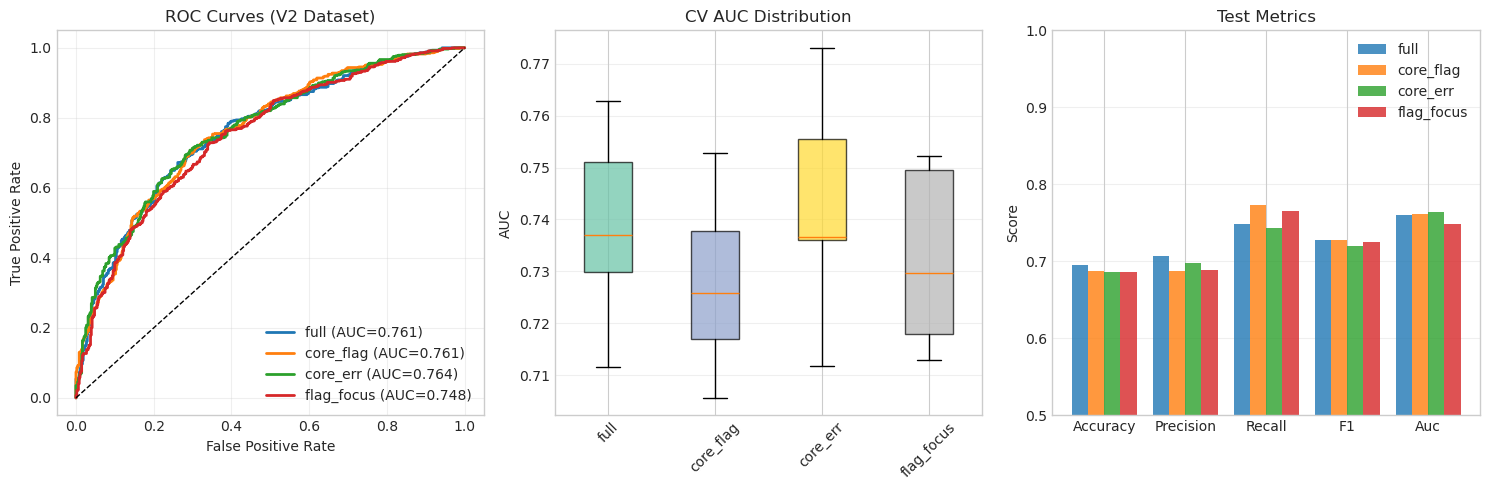

In [30]:
# ## Cell 9: Visualizations

# ROC curves
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax1 = axes[0]
for name, results in all_results.items():
    fpr, tpr, _ = roc_curve(y_test, results['y_pred_proba'])
    auc = results['test_metrics']['auc']
    ax1.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=2)
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves (V2 Dataset)')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# CV scores
ax2 = axes[1]
cv_data = [r['cv_scores'] for r in all_results. values()]
bp = ax2.boxplot(cv_data, labels=list(all_results.keys()), patch_artist=True)
colors = plt.cm.Set2(np.linspace(0, 1, len(all_results)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_ylabel('AUC')
ax2.set_title('CV AUC Distribution')
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45)

# Metrics comparison
ax3 = axes[2]
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
x = np.arange(len(metrics))
width = 0.2
for i, (name, results) in enumerate(all_results.items()):
    values = [results['test_metrics'][m] for m in metrics]
    ax3.bar(x + i*width, values, width, label=name, alpha=0.8)
ax3.set_ylabel('Score')
ax3.set_title('Test Metrics')
ax3.set_xticks(x + width * 1.5)
ax3.set_xticklabels([m.capitalize() for m in metrics])
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim([0.5, 1.0])

plt.tight_layout()
plt.show()

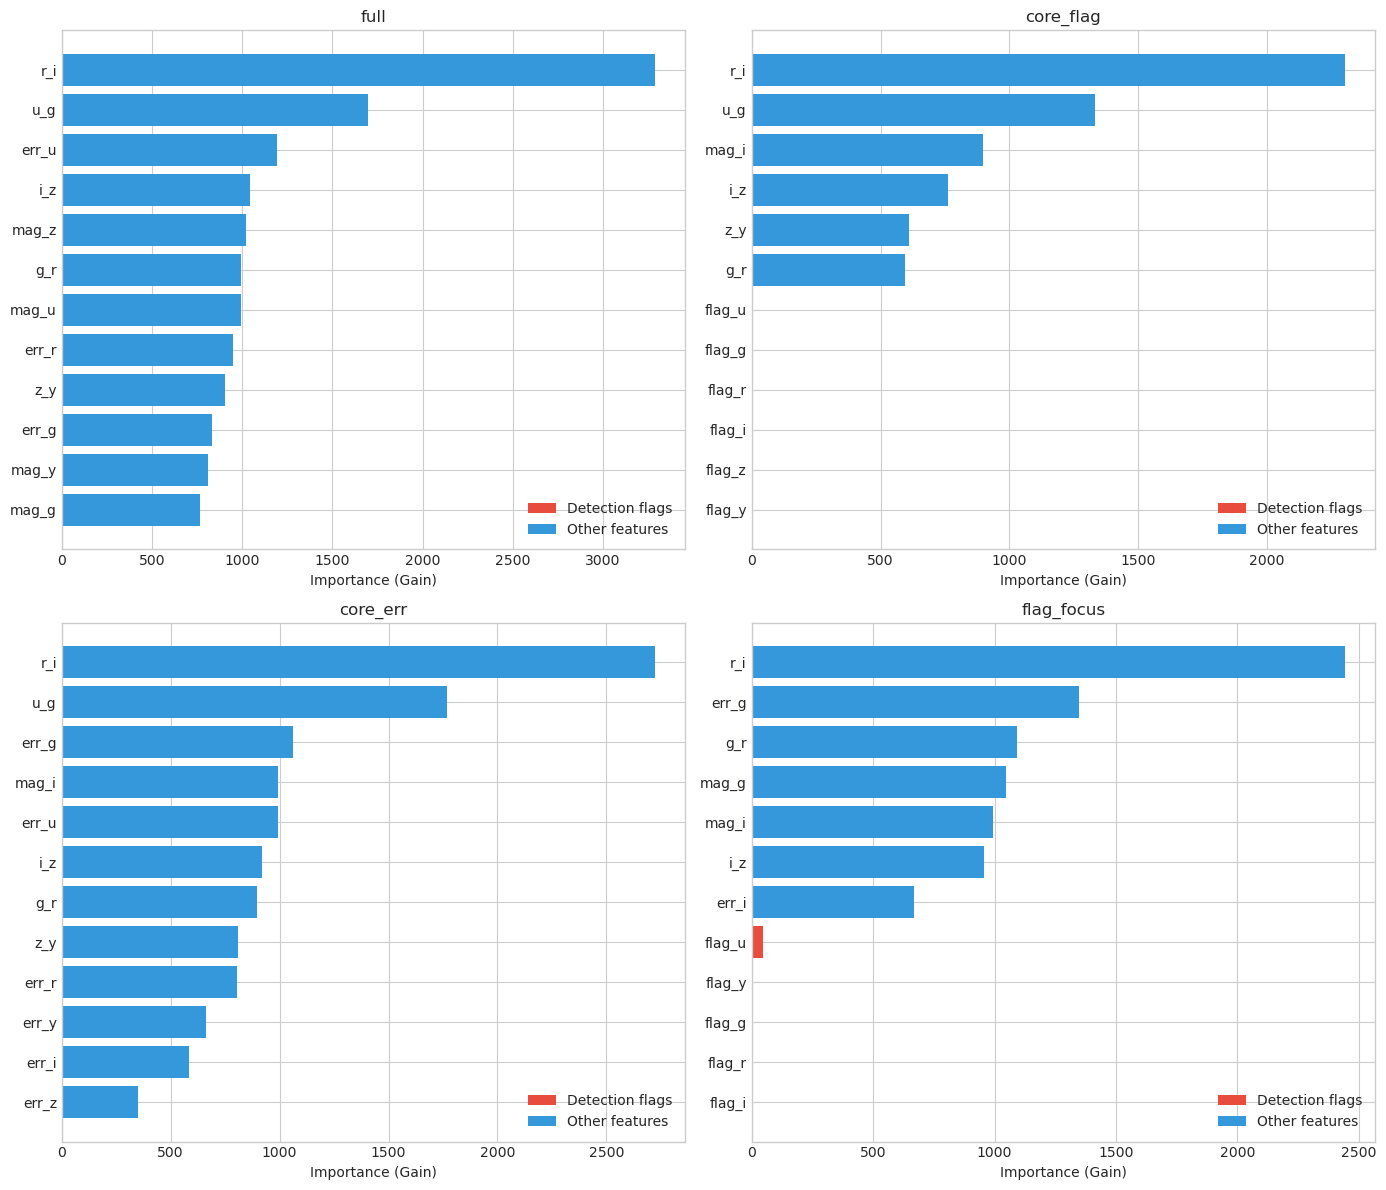

In [31]:
# ## Cell 10: Feature Importance (Focus on flag features)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (name, results) in zip(axes, all_results.items()):
    importance = results['feature_importance']. head(12)
    
    # Color flag features differently
    colors = ['#e74c3c' if 'flag' in f else '#3498db' 
              for f in importance['feature']]
    
    ax.barh(importance['feature'], importance['importance'], color=colors)
    ax.set_xlabel('Importance (Gain)')
    ax.set_title(f'{name}')
    ax.invert_yaxis()
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#e74c3c', label='Detection flags'),
        Patch(facecolor='#3498db', label='Other features')
    ]
    ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()